# Module 01: Descriptive Statistics and Distributions

## Week 01_Module 01_Part 01

---

## 1️⃣ Mean (গড়)

সব মান যোগ করে মোট সংখ্যা দিয়ে ভাগ করলে **Mean** পাওয়া যায়।

**Formula:**
$$Mean = \frac{\sum x_i}{n}$$

**উদাহরণ:**
Data: `[10, 12, 14, 16, 18, 100]`
$$Mean = \frac{10+12+14+16+18+100}{6} = 28.3$$

> ⚠️ **মনে রাখো:** Outlier (যেমন `100`) থাকলে Mean অনেকটা প্রভাবিত হয়ে যায়।

---

## 2️⃣ Median (মধ্যমান)

Data কে ছোট থেকে বড় ক্রমে সাজালে **ঠিক মাঝের মান**টাই হলো Median। এটি data-কে দুটি সমান ভাগে ভাগ করে।

**নিয়ম:**
- Data সংখ্যা **বেজোড়** হলে → মাঝের মানটি নাও
- Data সংখ্যা **জোড়** হলে → মাঝের দুটি মানের গড় নাও

**উদাহরণ:**
Sorted data: `[10, 12, 14, 16, 18, 100]`
$$Median = \frac{14+16}{2} = 15$$

> ✅ Outlier থাকলেও Median তেমন প্রভাবিত হয় না।

---

## 3️⃣ Mode (সর্বোচ্চ পুনরাবৃত্তি)

Dataset-এ যে মানটি **সবচেয়ে বেশিবার** আসে সেটাই **Mode**।

**উদাহরণ:**
Data: `[2, 2, 3, 3, 3, 4, 5]`
$$Mode = 3$$ *(৩ বার এসেছে)*

> 📌 একটি dataset-এ একাধিক Mode-ও থাকতে পারে।

---

## 📊 কোন Situation-এ কোন Measure ব্যবহার করবো?
## 🔀 Comparison Table

| Situation | Best Measure | কারণ |
|---|---|---|
| Symmetric data (যেমন height, temperature) | **Mean** | সব মান সমানভাবে contribute করে |
| Skewed data with outliers (যেমন income, price) | **Median** | Outlier-এ প্রভাবিত হয় না |
| Categorical data (যেমন color, gender) | **Mode** | Non-numeric data-তেও কাজ করে |

## ⚠️ Common Mistakes

> এই ভুলগুলো করা যাবে না!

- **Skewed data**-তে **Mean** ব্যবহার → ফলাফল **misleading** হয়
- **Categorical data**-তে **Median** ব্যবহার → সম্পূর্ণ **meaningless**
- **Continuous numeric data**-তে **Mode** ব্যবহার → খুব কমই কাজে আসে
- Missing values impute করার আগে **distribution** চেক না করা → বড় ভুল

## 📝 Final Summary

| Measure | কখন ব্যবহার করবো |
|---|---|
| **Mean** | Normal, balanced data-তে |
| **Median** | Skewed বা outlier-যুক্ত data-তে |
| **Mode** | Categorical data-তে |

## 🤖 Machine Learning-এ গুরুত্ব

**ML**-এ সঠিক measure বেছে নেওয়া খুবই জরুরি কারণ এটি —
- ✅ Data কে সঠিকভাবে **represent** করে
- ✅ Missing values বুদ্ধিমত্তার সাথে **fill** করতে সাহায্য করে
- ✅ আরও **accurate model** তৈরি করতে সহায়তা করে

---

## Week 01_Module 01_Part 02

In [1]:
import numpy as np
import pandas as pd

# Simple dataset (e.g., house prices in thousands)
data = [120, 125, 128, 122, 126, 124, 600]  # 600 is an outlier
df = pd.DataFrame({'HousePrice': data})
print(df)

# Mean
mean_value = df['HousePrice'].mean()
print("Mean:", mean_value)

   HousePrice
0         120
1         125
2         128
3         122
4         126
5         124
6         600
Mean: 192.14285714285714


In [2]:
median_value = df['HousePrice'].median()
print("Median:", median_value)

Median: 125.0


In [3]:
# Adding some categorical data
df['City'] = ['Dhaka', 'Dhaka', 'Chattogram', 'Sylhet', 'Dhaka', 'Rajshahi', 'Chattogram']
mode_value = df['City'].mode()[0]
print("Mode:", mode_value)

Mode: Dhaka


In [4]:
from sklearn.impute import SimpleImputer
imputer_mean = SimpleImputer(strategy='mean')
imputer_median = SimpleImputer(strategy='median')
imputer_mode = SimpleImputer(strategy='most_frequent')

## Week 01_Module 01_Part 03

---

## 📌 Variance কী?

**Variance** হলো data points গুলো mean থেকে গড়ে কতটা দূরে আছে তার **average squared deviation**।

## 🔢 Formula

### Population Variance (σ²)
> পুরো **population**-এর data থাকলে ব্যবহার করি

$$\sigma^2 = \frac{1}{n}\sum_{i=1}^{n}(x_i - \bar{x})^2$$

### Sample Variance (s²)
> **Population**-এর একটি অংশ (subset) থেকে হিসাব করলে ব্যবহার করি

$$s^2 = \frac{1}{n-1}\sum_{i=1}^{n}(x_i - \bar{x})^2$$

## ⚖️ Population vs Sample Variance

| | **Population Variance (σ²)** | **Sample Variance (s²)** |
|---|---|---|
| **Data** | পুরো population | Population-এর একটি subset |
| **ভাগ করি** | n দিয়ে | n−1 দিয়ে |
| **উদ্দেশ্য** | সরাসরি পরিমাপ | Population-কে estimate করা |

---

## 🔧 Bessel's Correction

Sample-এ **n** দিয়ে ভাগ করলে variance টা একটু **underestimate** হয়ে যায়। এই ভুল ঠিক করতেই **n−1** ব্যবহার করা হয় — এটাই **Bessel's Correction**।

> 💡 **কারণ:** Sample, population-এর পুরো variability ধরতে পারে না। n−1 ব্যবহারে result আরও **unbiased** হয়।

## 🧮 উদাহরণ — Data: `[70, 80, 90]`

**Step 1: Mean বের করো**
$$\bar{x} = \frac{70+80+90}{3} = 80$$

**Step 2: Mean থেকে পার্থক্যের বর্গ**

| Data Point | Calculation | Result |
|---|---|---|
| 70 | $(70-80)^2$ | 100 |
| 80 | $(80-80)^2$ | 0 |
| 90 | $(90-80)^2$ | 100 |


**Step 3: Variance হিসাব করো**

$$\sigma^2 \text{ (Population Variance)} = \frac{200}{3} \approx 66.67$$

$$s^2 \text{ (Sample Variance)} = \frac{200}{3-1} = \frac{200}{2} = 100$$

> ⚠️ **লক্ষ্য করো:** Sample Variance সবসময় Population Variance-এর চেয়ে **একটু বেশি** হয়। কারণ আমরা ছোট সংখ্যা **(n−1)** দিয়ে ভাগ করি — এটাই **Bessel's Correction**-এর উদ্দেশ্য, যাতে **bias** দূর হয়।

> ✅ **মনে রাখো:** Real-world-এ সাধারণত পুরো population পাওয়া যায় না, তাই **Sample Variance** বেশি ব্যবহৃত হয়।

---

## 📌 Standard Deviation কী?

**Standard Deviation (SD)** হলো **Variance**-এর **square root**। এটি data কতটা ছড়িয়ে আছে তা **data-র মতো একই unit**-এ প্রকাশ করে।

## 🔢 Formula

$$\sigma = \sqrt{\sigma^2} \quad \text{(Population SD)}$$

$$s = \sqrt{s^2} \quad \text{(Sample SD)}$$

## 🏠 উদাহরণ

গড় বাড়ির দাম **$200K**, SD = **$50K** হলে —
বেশিরভাগ বাড়ির দাম **$150K – $250K**-এর মধ্যে থাকবে।

---

## 🤖 ML Pipeline-এ Variance ও SD-এর ব্যবহার

### 1️⃣ Feature Scaling (Standardization)
প্রতিটি feature-কে তুলনাযোগ্য করতে **Standardization** ব্যবহার হয়, যেখানে —
- **Mean = 0**
- **SD = 1**

$$z_i = \frac{x_i - \mu}{\sigma}$$

### 2️⃣ Regularization
**Ridge** ও **Lasso** coefficient-এর variance কমিয়ে **overfitting** রোধ করে।

### 3️⃣ Model Diagnostics
বিভিন্ন **fold**-এ model performance-এ **high variance** থাকলে বুঝতে হবে model **unstable**।

---

# ⚖️ Bias-Variance Trade-off

## 📌 Variance in Model Evaluation

Model evaluation-এ **Variance** মানে — training data বদলালে model-এর **prediction কতটা বদলে যায়**।

## 🔍 High vs Low Variance

| অবস্থা | কী হয় | সমস্যা |
|---|---|---|
| **High Variance** | Model, training data মুখস্থ করে ফেলে | **Overfitting** |
| **Low Variance + High Bias** | Model খুব সরলভাবে শেখে | **Underfitting** |

## ⚠️ দুটি আলাদা Variance Concept

> **Data-র Variance** ≠ **Model Parameter-এর Variance**

কিন্তু দুটির **intuition একই** —
> 💡 *"Spread-এর কারণে instability"*

## 🎯 সহজ মনে রাখার উপায়

```
High Variance  →  Overfit  →  Training-এ ভালো, Test-এ খারাপ
High Bias      →  Underfit →  Training ও Test দুটোতেই খারাপ
```

> ✅ **মনে রাখো:** Variance unit হয় **বর্গ** (যেমন kg²), কিন্তু SD মূল data-র মতোই **same unit**-এ থাকে — তাই SD বেশি সহজবোধ্য।

> ✅ **লক্ষ্য:** Bias ও Variance-এর মধ্যে সঠিক **balance** খুঁজে বের করাই হলো ভালো ML model তৈরির মূল চ্যালেঞ্জ।

---

## 🔄 Variance vs Standard Deviation - Comparison Table

| | **Variance** | **Standard Deviation** |
|---|---|---|
| **Definition** | Squared deviations-এর গড় | Variance-এর square root |
| **Formula** | $\frac{\sum(x-\mu)^2}{n}$ বা $\frac{\sum(x-\bar{x})^2}{n-1}$ | $\sqrt{Variance}$ |
| **Unit** | Squared unit (যেমন $^2) | Data-র মতোই (যেমন $) |
| **Interpretation** | Mathematical measure | Intuitive spread |
| **ব্যবহার** | Theoretical/statistical analysis | Communication & scaling |

> 💡 দুটোই variability পরিমাপ করে, কিন্তু **SD** বোঝা সহজ কারণ এটি data-র **same scale**-এ থাকে।

---

## 🧮 উদাহরণ — Data: `[70, 80, 90]`

আগে থেকেই জানি → **Population Variance = 66.67**

$$\sigma = \sqrt{66.67} \approx 8.16$$

### ✅ Interpretation:
- **Variance = 66.67** → Squared unit, তাই সরাসরি বোঝা কঠিন
- **SD = 8.16** → মানে scores গুলো mean থেকে সাধারণত **±8 points** দূরে থাকে

> ✅ **মনে রাখো:** Practical কাজে **SD** বেশি ব্যবহার হয় কারণ এটি **intuitive** এবং data-র মতোই **same unit**-এ প্রকাশিত হয়।

---

In [5]:
data = [10, 12, 13, 15, 18]
print("Variance:", np.var(data))
print("Standard Deviation:", np.std(data))

Variance: 7.44
Standard Deviation: 2.727636339397171


In [6]:
import numpy as np
import pandas as pd

# Monthly customer purchase amounts
data = [120, 130, 125, 140, 135, 200, 220]
df = pd.DataFrame({'Purchase': data})

mean = np.mean(df['Purchase'])
pop_var = np.var(df['Purchase'], ddof=0)   # population variance
samp_var = np.var(df['Purchase'], ddof=1)  # sample variance
pop_sd = np.std(df['Purchase'], ddof=0)    # population SD
samp_sd = np.std(df['Purchase'], ddof=1)   # sample SD

print("Mean:", mean)
print("Population Variance:", pop_var)
print("Sample Variance:", samp_var)
print("Population SD:", pop_sd)
print("Sample SD:", samp_sd)

Mean: 152.85714285714286
Population Variance: 1370.4081632653058
Sample Variance: 1598.8095238095236
Population SD: 37.019024342428395
Sample SD: 39.98511627855449


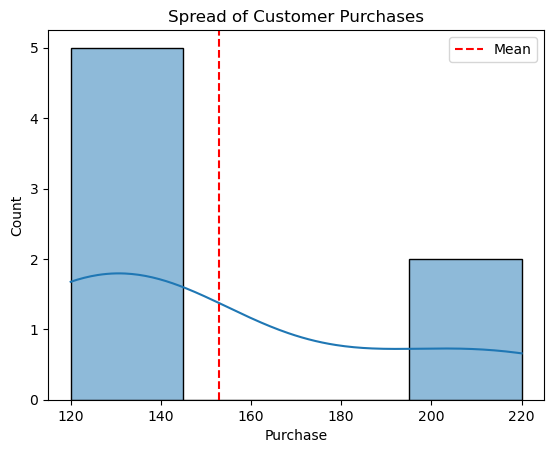

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df['Purchase'], kde=True)
plt.axvline(mean, color='red', linestyle='--', label='Mean')
plt.legend()
plt.title('Spread of Customer Purchases')
plt.show()

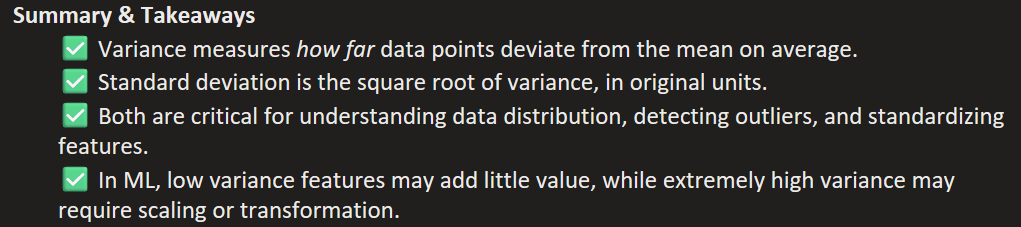

## 🔑 মূল বিষয়গুলো

**১. Variance**
> Data points গুলো গড়ে mean থেকে **কতটা দূরে** আছে তা পরিমাপ করে।

**২. Standard Deviation**
> Variance-এর **square root** — original unit-এ প্রকাশিত হয়, তাই বুঝতে সহজ।

**৩. দুটোই জরুরি কারণ —**
- ✅ Data distribution বোঝা যায়
- ✅ Outlier detect করা যায়
- ✅ Features standardize করা যায়

## 🤖 ML-এ গুরুত্ব

| Variance-এর মাত্রা | কী করতে হবে |
|---|---|
| **Low Variance** | Feature টি model-এ কম value add করে, বাদ দেওয়া যেতে পারে |
| **Extremely High Variance** | **Scaling** বা **Transformation** দরকার |

> 💡 **এক কথায়:** Variance ও SD — দুটোই data-র **ছড়িয়ে পড়া** বোঝার এবং ML model-কে **সঠিকভাবে train** করার জন্য অপরিহার্য।

---

## Week 01_Module 01_Part 04

1. **Percentiles & Quartiles** — Data ভাগ করা
2. **IQR (Interquartile Range)** — মাঝের 50% data-র spread
3. **Z-Score** — Mean থেকে কতটা দূরে
4. **Python Implementation & Outlier Detection** — বাস্তব প্রয়োগ

---

## 📌 Percentile কী?

**Percentile** বলে — একটি নির্দিষ্ট মানের **নিচে** মোট data-র কত **শতাংশ** আছে।

> 🎯 **উদাহরণ:** তোমার test score যদি **90th percentile**-এ থাকে, তাহলে তুমি **90%** মানুষের চেয়ে ভালো করেছো।

## 🔢 Formula

$$\text{Percentile Rank} = \frac{\text{number of values below } x}{\text{total number of values}} \times 100$$

---

## 🔀 Quartiles কী?

**Quartiles** হলো বিশেষ **Percentile** যা data-কে **চারটি** সমান ভাগে ভাগ করে।

| Quartile | Percentile | অর্থ |
|---|---|---|
| **Q1** | 25th | Data-র **25%** এর নিচে |
| **Q2** | 50th | এটাই **Median** |
| **Q3** | 75th | Data-র **75%** এর নিচে |

> ✅ **মনে রাখো:** Q1, Q2, Q3 মিলে data-র **distribution** সম্পর্কে দ্রুত একটি স্পষ্ট ধারণা পাওয়া যায়।

---

## 🤖 ML-এ Percentile-এর ব্যবহার

**Outlier** handle করতে **Percentile** খুব কাজে আসে।

> 💡 Numerical features **preprocess** করার সময় —
> - **1st percentile**-এর **নিচের** মান → বাদ দাও
> - **99th percentile**-এর **উপরের** মান → বাদ দাও
>
> এতে **extreme data points**-এর প্রভাব কমে যায়।

---

## 📌 Interquartile Range (IQR) কী?

**IQR** হলো data-র **মাঝের 50%** কতটা ছড়িয়ে আছে তার পরিমাপ।

$$IQR = Q3 - Q1$$

## 🔍 Interpretation

| IQR-এর মাত্রা | অর্থ |
|---|---|
| **Small IQR** | Data points কাছাকাছি — **tightly packed** |
| **Large IQR** | Data-তে **high variability** আছে |

---

## 🚨 Outlier Detection Rule

$$\text{Lower Bound} = Q1 - 1.5 \times IQR$$
$$\text{Upper Bound} = Q3 + 1.5 \times IQR$$

> ⚠️ এই **দুই সীমার বাইরে** যেকোনো মান → **Outlier**

---

## 🤖 ML-এ IQR-এর ব্যবহার

Model **train** করার আগে **IQR-based filtering** করা হয় যাতে extreme values result **skew** না করে।

**বিশেষত গুরুত্বপূর্ণ —**
- 🏠 **Housing price prediction** — কিছু অস্বাভাবিক বড় মান model-কে বিভ্রান্ত করতে পারে
- 💰 **Salary dataset** — কয়েকটি অতি উচ্চ বেতন model-এর স্বাভাবিক আচরণ বোঝার ক্ষমতা নষ্ট করে

> ✅ **মনে রাখো:** IQR, **Outlier detect** করার সবচেয়ে নির্ভরযোগ্য পদ্ধতিগুলোর একটি কারণ এটি Mean বা SD-এর মতো Outlier দ্বারা প্রভাবিত হয় না।

---

## 📌 Z-Score কী?

**Z-Score** বলে — একটি মান, mean থেকে কতটি **standard deviation** দূরে আছে।

---

## 🔢 Formula

$$z = \frac{x - \mu}{\sigma}$$

| চিহ্ন | অর্থ |
|---|---|
| $x$ | Individual value |
| $\mu$ | Dataset-এর mean |
| $\sigma$ | Standard deviation |

> 💡 Z-Score করার পর → **Mean = 0, SD = 1**

---

## 🔍 Interpretation

| Z-Score | অর্থ |
|---|---|
| **z = 0** | মানটি ঠিক **mean**-এ আছে |
| **z = 1** | Mean-এর **1 SD উপরে** |
| **z = -2** | Mean-এর **2 SD নিচে** |

> ⚠️ সাধারণত **\|z\| > 3** হলে সেটি **Outlier** হিসেবে ধরা হয়।

---

## 🤖 ML-এ Z-Score-এর ব্যবহার

**Z-Score Normalization** হলো **Standard Scaling**-এর মূল ভিত্তি — এটি সব features-কে **Mean = 0** ও **SD = 1**-এ রূপান্তর করে।

**বিশেষত জরুরি এই model-গুলোর জন্য —**
- 🔵 **KNN** — distance-based, scale-sensitive
- 🔴 **SVM** — margin-based, scale-sensitive
- 🟡 **Gradient Descent-based models** — feature scale-এ সংবেদনশীল

> ✅ **মনে রাখো:** Features-এর scale আলাদা হলে model **bias** হয়ে যায় — **Z-Score** সেটি ঠিক করে।

---

## 🗂️ Quick Summary Table

| Concept | Formula | ML-এ ব্যবহার |
|---|---|---|
| **Percentile** | Position measure | Feature understanding |
| **Quartile** | Q1, Q2, Q3 (25th, 50th, 75th) | Spread summary |
| **IQR** | Q3 − Q1 | Outlier detection |
| **Z-Score** | $(x-\mu)/\sigma$ | Standardization & scaling |

---

In [8]:
import numpy as np

data = [10, 12, 13, 15, 18, 21, 23, 25, 28, 30, 34, 35, 37, 40]
print("25th percentile (Q1):", np.percentile(data, 25))
print("50th percentile (Median):", np.percentile(data, 50))
print("75th percentile (Q3):", np.percentile(data, 75))

25th percentile (Q1): 15.75
50th percentile (Median): 24.0
75th percentile (Q3): 33.0


In [9]:
Q1 = np.percentile(data, 25)
Q3 = np.percentile(data, 75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("IQR:", IQR)
print("Outlier Range:", lower_bound, "to", upper_bound)

IQR: 17.25
Outlier Range: -10.125 to 58.875


In [10]:
import numpy as np

data = np.array([10, 12, 13, 15, 18, 21, 23, 25, 28, 30, 34, 35, 37, 40])
mean = np.mean(data)
std = np.std(data)

z_scores = [(x - mean) / std for x in data]
print("Z-scores:", np.round(z_scores, 2))

Z-scores: [-1.5  -1.29 -1.19 -0.98 -0.66 -0.35 -0.14  0.07  0.38  0.59  1.01  1.11
  1.32  1.63]


In [11]:
import pandas as pd
import numpy as np

df = pd.DataFrame({'Income': [22, 25, 27, 29, 35, 40, 42, 100, 110, 115]})

# IQR পদ্ধতি
Q1 = df['Income'].quantile(0.25)
Q3 = df['Income'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.0 * IQR
upper = Q3 + 1.0 * IQR
outliers_iqr = df[(df['Income'] < lower) | (df['Income'] > upper)]

print("Outliers using IQR:\n", outliers_iqr)

# Z-score পদ্ধতি
mean = df['Income'].mean()
std = df['Income'].std()
df['z_score'] = (df['Income'] - mean) / std
outliers_z = df[np.abs(df['z_score']) > 2.5]
print("Outliers using Z-score:\n", outliers_z)

# Modified Z-score (Robust)
median = df['Income'].median()
mad = np.median(np.abs(df['Income'] - median))
df['mod_z'] = 0.6745 * (df['Income'] - median) / mad
outliers_mz = df[np.abs(df['mod_z']) > 3.5]
print("Outliers using Modified Z-score:\n", outliers_mz)
# MAD = Median of those deviations

Outliers using IQR:
 Empty DataFrame
Columns: [Income]
Index: []
Outliers using Z-score:
 Empty DataFrame
Columns: [Income, z_score]
Index: []
Outliers using Modified Z-score:
    Income   z_score     mod_z
7     100  1.202258  3.665761
8     110  1.466491  4.252283
9     115  1.598607  4.545543


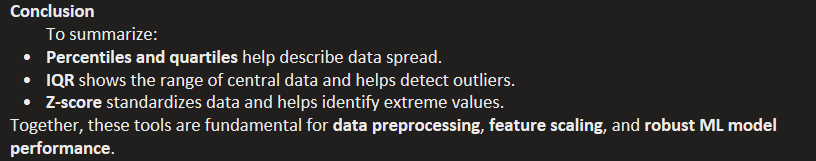

---

## Week 01_Module 01_Part 05

## 📊 Distribution Shapes

Distribution-এর **আকৃতি** কীভাবে ML model-কে প্রভাবিত করে তা বোঝা এবং **IQR fences** দিয়ে outlier detect করা।

---## 📚 এই Module-এ যা শিখবো

- ✅ **Symmetric vs Skewed** distribution visualize করা
- ✅ **Long tails** কেমন দেখতে এবং কেন গুরুত্বপূর্ণ
- ✅ Code দিয়ে **IQR fences** ব্যবহার করে outlier detect করা

---

## 🔔 Symmetric Distribution

**Symmetric distribution** দেখতে তার কেন্দ্রের **দুই পাশে একই রকম**।

সবচেয়ে পরিচিত উদাহরণ → **Normal Distribution**

> 💡 **বিশেষ বৈশিষ্ট্য:**
> Symmetric distribution-এ **Mean, Median ও Mode** তিনটিই **একই জায়গায়** (center-এ) থাকে।
> ✅ **মনে রাখো:** Distribution-এর shape জানা জরুরি কারণ এটি নির্ধারণ করে কোন **statistical measure** ও কোন **ML algorithm** ব্যবহার করা উচিত।

---

## 🔔 Symmetric Distribution

**Symmetric distribution** দেখতে তার কেন্দ্রের **দুই পাশে একই রকম**।

সবচেয়ে পরিচিত উদাহরণ → **Normal Distribution**

### 🔑 মূল বৈশিষ্ট্য:
- Distribution-টি center-এর **বাম ও ডান দিক** — দুটো **mirror image**
- **Mean = Median = Mode** — তিনটিই ঠিক **center**-এ অবস্থান করে
- Data **সমানভাবে** center-এর দুই পাশে ছড়িয়ে থাকে

> ✅ **Symmetric data**-তে **Mean** ব্যবহার করা সবচেয়ে নির্ভরযোগ্য কারণ কোনো **outlier** বা **skewness** নেই।

---

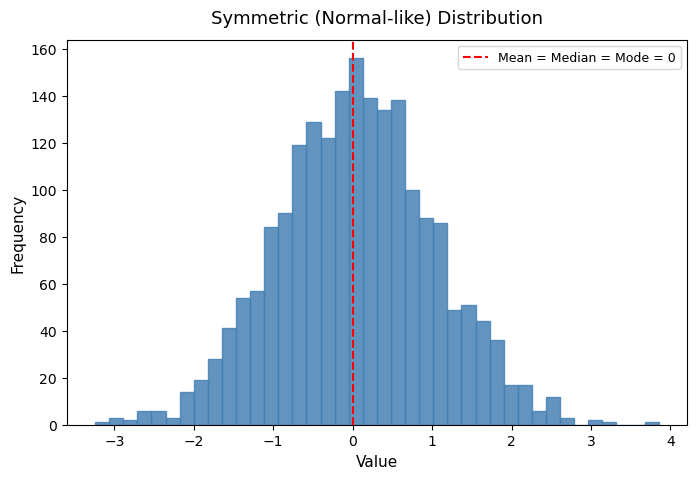

In [12]:
import numpy as np
import matplotlib.pyplot as plt

# ── Dataset তৈরি ──
np.random.seed(42)
data = np.random.normal(loc=0, scale=1, size=2000)  # mean=0, sd=1

# ── Plot তৈরি ──
fig, ax = plt.subplots(figsize=(8, 5))

# Histogram
plt.hist(data, bins=40, color='steelblue', edgecolor='steelblue', alpha=0.85, density=False)

# Normal curve (frequency scale এ)
x = np.linspace(data.min(), data.max(), 300)
bin_width = (data.max() - data.min()) / 40

# Mean / Median / Mode line (তিনটিই center এ)
ax.axvline(x=0, color='red', linewidth=1.5, linestyle='--', label='Mean = Median = Mode = 0')

# Labels & Title
ax.set_title('Symmetric (Normal-like) Distribution', fontsize=13, pad=12)
ax.set_xlabel('Value', fontsize=11)
ax.set_ylabel('Frequency', fontsize=11)
ax.legend(fontsize=9)

plt.show()

## 🤖 ML Focus

অনেক **ML algorithm** ধরে নেয় যে features **roughly normal distribution** follow করে — তখনই এগুলো সবচেয়ে ভালো কাজ করে।

| Algorithm | Normal Distribution ধরে নেয়? |
|---|---|
| **Linear Regression** | ✅ হ্যাঁ |
| **SVM** | ✅ হ্যাঁ |
| **KNN** | ✅ হ্যাঁ |

> 💡 Data যদি **symmetric** হয়, তাহলে আলাদা কোনো **transformation** দরকার হয় না — সরাসরি model-এ দেওয়া যায়।

---

## 📌 Skewed Distribution কী?

**Skewed distribution** হলো এমন distribution যা **symmetric নয়** — অর্থাৎ দুই পাশ সমান নয়।

এটি দুই ধরনের হয়:

| ধরন | অন্য নাম | বৈশিষ্ট্য |
|---|---|---|
| **Positively Skewed** | Right-skewed | লেজ **ডান দিকে** লম্বা |
| **Negatively Skewed** | Left-skewed | লেজ **বাম দিকে** লম্বা |

> ✅ **মনে রাখো:** Skewed data-তে **Mean** ব্যবহার না করে **Median** ব্যবহার করা উচিত — কারণ **outlier** mean-কে টেনে নিয়ে যায়।

---

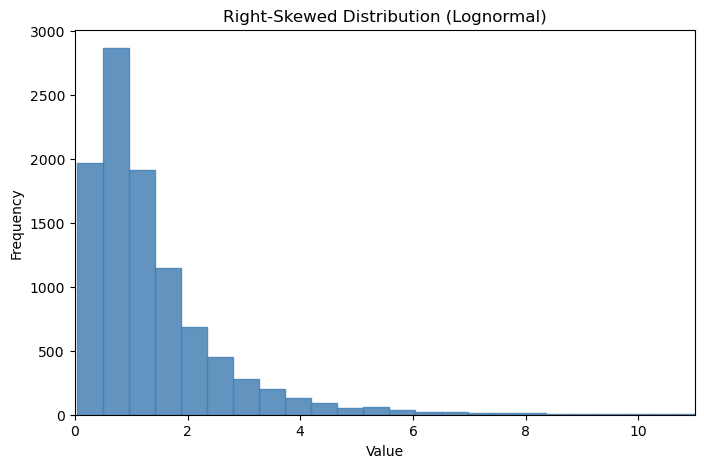

In [13]:
import numpy as np
import matplotlib.pyplot as plt
# from scipy.stats import lognorm

# Dataset তৈরি
np.random.seed(42)
data = np.random.lognormal(mean=0, sigma=0.8, size=10000)

# Plot
fig, ax = plt.subplots(figsize=(8, 5))

# Histogram
ax.hist(data, bins=50, color='steelblue', edgecolor='steelblue', alpha=0.85, density=False)

# Lognormal curve
x = np.linspace(0.01, data.max(), 300)
bin_width = (data.max() - data.min()) / 50
# pdf_scaled = lognorm.pdf(x, s=0.8, scale=np.exp(0)) * len(data) * bin_width
# ax.plot(x, pdf_scaled, color='red', linewidth=2)

# Labels & Title
ax.set_title('Right-Skewed Distribution (Lognormal)')
ax.set_xlabel('Value')
ax.set_ylabel('Frequency')
ax.set_xlim(0, 11)

plt.show()

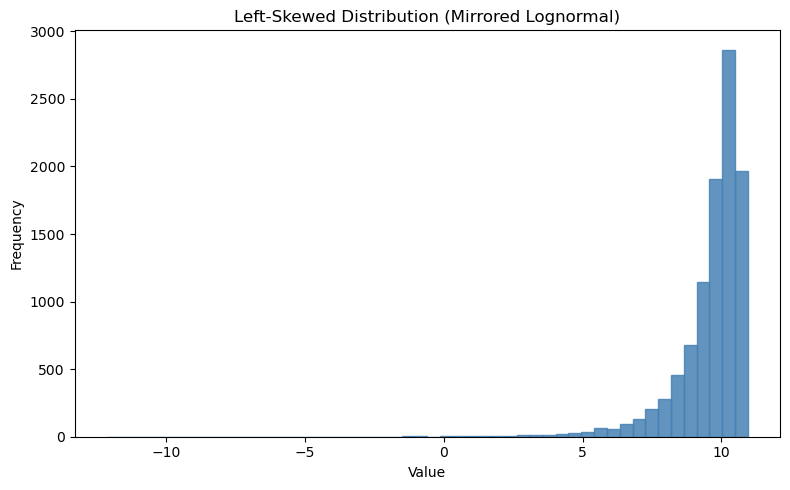

In [14]:
import numpy as np
import matplotlib.pyplot as plt

# Dataset তৈরি (Mirrored Lognormal = Left-Skewed)
np.random.seed(42)
data = -np.random.lognormal(mean=0, sigma=0.8, size=10000) + 11

# Plot
fig, ax = plt.subplots(figsize=(8, 5))

# Histogram
ax.hist(data, bins=50, color='steelblue', edgecolor='steelblue', alpha=0.85)

# Labels & Title
ax.set_title('Left-Skewed Distribution (Mirrored Lognormal)')
ax.set_xlabel('Value')
ax.set_ylabel('Frequency')

plt.tight_layout()
# plt.savefig('/mnt/user-data/outputs/left_skewed_distribution.png', dpi=150)
plt.show()

## 🤖 ML Focus — Skewed Data

**Right-skewed data** সাধারণত এই ধরনের dataset-এ দেখা যায়:
- 💰 Income
- 🏠 Price
- ⏱️ Reaction time

> ⚠️ **সমস্যা:** Skewness থাকলে ML model-এর **accuracy কমে** যায় এবং **bias** তৈরি হয়।

### 🔧 সমাধান — Transformation প্রয়োগ করো:

| Transformation | কখন ব্যবহার করবো |
|---|---|
| **Log Transformation** | সবচেয়ে সহজ ও common |
| **Box-Cox** | শুধু positive data-তে কাজ করে |
| **Yeo-Johnson** | Positive ও negative উভয় data-তে কাজ করে |

### 🏠 উদাহরণ:
House price prediction-এ **price column**-এ **log transform** প্রয়োগ করলে model আরও **stable** ও **accurate** হয়।

---

## 📌 Long Tail কী?

**Long Tail** মানে — distribution-এর কিছু **extreme value** center থেকে অনেক দূরে **লম্বা লেজের** মতো ছড়িয়ে থাকে।

---

## 🌍 Real-world উদাহরণ

**Long-tailed distribution** বাস্তব জীবনে খুবই সাধারণ:

| Dataset | কারণ |
|---|---|
| 👥 **User engagement** | অল্প কিছু user বেশিরভাগ সময় কাটায় |
| 📱 **Social media followers** | কিছু account-এ লক্ষ লক্ষ follower, বাকিদের খুব কম |

> ⚠️ **মূল বৈশিষ্ট্য:** মাত্র **কয়েকটি point** পুরো range-কে **dominate** করে।
> ✅ **ML-এ সতর্কতা:** Long-tailed data সরাসরি model-এ দিলে **bias** হয় — তাই আগে **log transformation** বা **capping** করা দরকার।

---

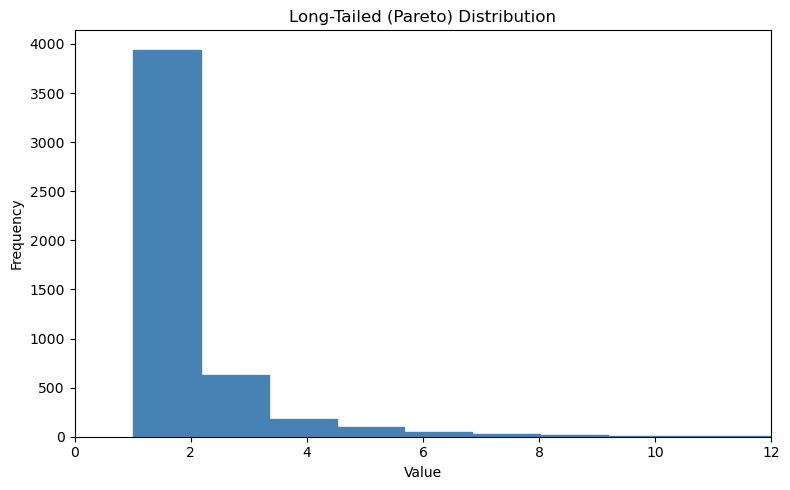

In [15]:
import numpy as np
import matplotlib.pyplot as plt

# Dataset তৈরি (Pareto = Long-Tailed)
np.random.seed(42)
data = np.random.pareto(a=2, size=5000) + 1  # +1 shift to start from 1

# Plot
fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(data, bins=50, color='steelblue', edgecolor='steelblue')

ax.set_title('Long-Tailed (Pareto) Distribution')
ax.set_xlabel('Value')
ax.set_ylabel('Frequency')
ax.set_xlim(0, 12)

plt.tight_layout()
# plt.savefig('/mnt/user-data/outputs/long_tailed_distribution.png', dpi=150)
plt.show()

## 🤖 ML Focus

**Long-tailed data** ML model-এর জন্য কঠিন চ্যালেঞ্জ তৈরি করে:

> ⚠️ Model, **frequent cases**-এ overfit করে এবং **rare কিন্তু গুরুত্বপূর্ণ** ঘটনা ignore করে।

**বিশেষত ক্ষতিকর —**
- 🔍 **Fraud detection**
- 🏥 **Rare disease prediction**

### 🔧 সমাধান:
- **Data normalization**
- **Resampling** (oversample rare cases)
- **Outlier-aware models** ব্যবহার

---

## 📋 Skewness vs Long Tail — এক নজরে

| Concept | Focus | অর্থ | উদাহরণ |
|---|---|---|---|
| **Skewness** | Asymmetry | Data কোন দিকে হেলে আছে | Income distribution (right-skewed) |
| **Long Tail** | Tail length & thickness | Rare/extreme value কতটা বিস্তৃত | YouTube video views (long right tail) |

---

# 🚨 Outlier Detection using IQR Fences

## 📌 Outlier কী?

**Outlier** হলো এমন data point যা বাকি সব observation থেকে **অনেক আলাদা**। এটি model training-কে **distort** করে এবং performance **কমিয়ে** দেয়।

> ✅ সবচেয়ে সহজ ও কার্যকর পদ্ধতি → **IQR** ব্যবহার করে outlier detect করা।

---

## 🔢 Step-by-Step পদ্ধতি

| ধাপ | কাজ | Formula |
|---|---|---|
| **1** | Q1 বের করো | 25th percentile |
| **2** | Q3 বের করো | 75th percentile |
| **3** | IQR বের করো | $Q3 - Q1$ |
| **4** | Lower Fence | $Q1 - 1.5 \times IQR$ |
| **5** | Upper Fence | $Q3 + 1.5 \times IQR$ |

> ⚠️ **Lower Fence-এর নিচে** বা **Upper Fence-এর উপরে** যেকোনো data point → **Outlier**

---

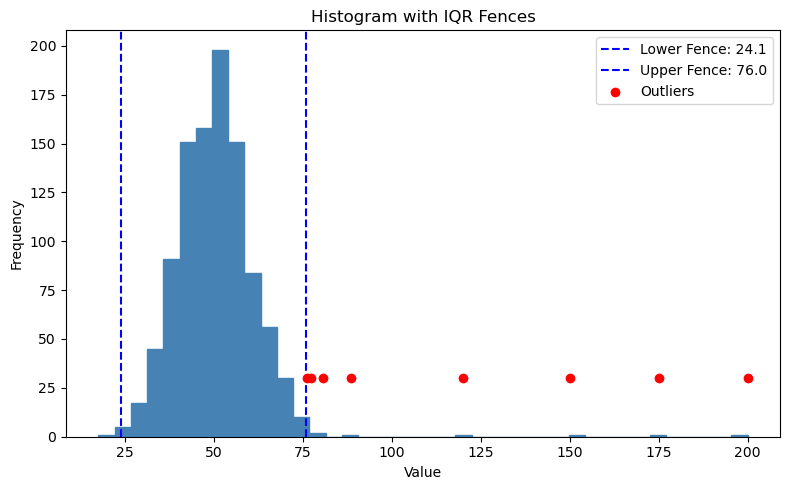

In [16]:
import numpy as np
import matplotlib.pyplot as plt

# Dataset তৈরি
np.random.seed(42)
data = np.concatenate([
    np.random.normal(loc=50, scale=10, size=1000),  # main data
    [120, 150, 175, 200]                             # outliers
])

# IQR Fences হিসাব
Q1 = np.percentile(data, 25)
Q3 = np.percentile(data, 75)
IQR = Q3 - Q1
lower_fence = Q1 - 1.5 * IQR
upper_fence = Q3 + 1.5 * IQR

# Outliers
outliers = data[data > upper_fence]

# Plot
fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(data, bins=40, color='steelblue', edgecolor='steelblue')
ax.axvline(lower_fence, color='blue', linestyle='--', label=f'Lower Fence: {lower_fence:.1f}')
ax.axvline(upper_fence, color='blue', linestyle='--', label=f'Upper Fence: {upper_fence:.1f}')
ax.scatter(outliers, [30] * len(outliers), color='red', zorder=5, label='Outliers')

ax.set_title('Histogram with IQR Fences')
ax.set_xlabel('Value')
ax.set_ylabel('Frequency')
ax.legend()

plt.tight_layout()
# plt.savefig('/mnt/user-data/outputs/iqr_fences.png', dpi=150)
plt.show()

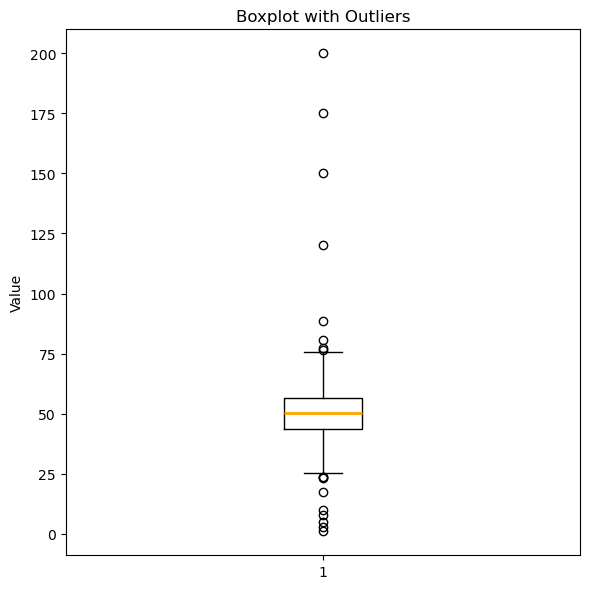

In [17]:
import numpy as np
import matplotlib.pyplot as plt

# Dataset তৈরি
np.random.seed(42)
data = np.concatenate([
    np.random.normal(loc=50, scale=10, size=1000),  # main data
    [120, 150, 175, 200],                            # upper outliers
    [1, 3, 5, 8, 10]                                 # lower outliers
])

# Plot
fig, ax = plt.subplots(figsize=(6, 6))

ax.boxplot(data, patch_artist=False,
           medianprops=dict(color='orange', linewidth=2))

ax.set_title('Boxplot with Outliers')
ax.set_ylabel('Value')

plt.tight_layout()
# plt.savefig('/mnt/user-data/outputs/boxplot_outliers.png', dpi=150)
plt.show()

---

## 🧮 উদাহরণ

$$Q1 = 30, \quad Q3 = 70 \quad \Rightarrow \quad IQR = 40$$

$$\text{Lower Fence} = 30 - 1.5 \times 40 = -30$$
$$\text{Upper Fence} = 70 + 1.5 \times 40 = 130$$

> ⚠️ যেসব মান **-30-এর নিচে** বা **130-এর উপরে** → সেগুলো **Outlier**

---

## 🤖 ML Focus

ML **preprocessing**-এ outlier **remove** বা **cap** করলে model আরও **robust** হয়।

বিশেষত যেসব model **scale-sensitive** তাদের জন্য খুব জরুরি:
- 📈 **Linear Regression**
- 📍 **KNN**

---

# 🔍 Outlier — রাখবো নাকি সরাবো?

## ⚖️ সব Outlier খারাপ নয়!

কিছু ML problem-এ outlier আসলে **সবচেয়ে গুরুত্বপূর্ণ** case:

| সমস্যা | Outlier মানে |
|---|---|
| 🔍 **Fraud detection** | সন্দেহজনক transaction |
| 🏥 **Medical diagnosis** | বিরল কিন্তু critical রোগী |

> 💡 এক্ষেত্রে outlier **remove না করে** আলাদাভাবে **label** বা **model** করতে হয়।

---

## ✅ Recap & Summary

| | মূল কথা |
|---|---|
| 🔵 | **Symmetric distribution** → ML model আরও **stable** হয় |
| 🟡 | **Skewed / Long-tailed data** → **Transformation** দরকার |
| 🟢 | **IQR** → দ্রুত ও কার্যকর **outlier detection** পদ্ধতি |
| 🔴 | Outlier দেখলেই সরাবে না — **noise নাকি insight** আগে বোঝো |

> 🎯 **সবচেয়ে গুরুত্বপূর্ণ কথা:** Data-র **shape বোঝাই** হলো trustworthy ML model তৈরির **প্রথম ধাপ**।

---

# 📝 Quick Recap & Mean/SD-এর সীমাবদ্ধতা

## 🔄 মূল Measures — এক নজরে

| Measure | কী করে |
|---|---|
| **Mean** | Data-র arithmetic গড় → **center** বোঝায় |
| **Median** | Sort করা data-র মাঝের মান |
| **SD** | Data points mean থেকে কতটা দূরে — **spread** বোঝায় |
| **IQR** | 75th − 25th percentile → মাঝের **50% data** capture করে |

> 💡 Mean+SD এবং Median+IQR — দুটো pair **center** ও **spread** মাপে, কিন্তু **outlier** বা **skewness** থাকলে আচরণ সম্পূর্ণ আলাদা।

---

## ⚠️ Mean ও SD কখন ব্যর্থ হয়?

**Symmetric, normally distributed data**-তে (যেমন height, IQ score) Mean ও SD দারুণ কাজ করে।

কিন্তু **outlier** থাকলে Mean চরম দিকে **টেনে যায়**।

### 🧮 উদাহরণ:
```python
import numpy as np
data = [25, 27, 28, 29, 30, 31, 35, 500]  # একটি বড় outlier
print("Mean:", np.mean(data))     # অনেক বেশি হয়ে যাবে
print("Median:", np.median(data)) # স্থিরই থাকবে
```

> ✅ Mean অনেক বেড়ে যায়, কিন্তু Median **স্থির** থাকে — এজন্যই Median-কে **robust measure** বলা হয়।

---

In [18]:
import numpy as np
data = [25, 27, 28, 29, 30, 31, 35, 500]  # একটি বড় outlier
print("Mean:", np.mean(data))     # অনেক বেশি হয়ে যাবে
print("Median:", np.median(data)) # স্থিরই থাকবে

Mean: 88.125
Median: 29.5


---

# 📊 কখন কোনটা ব্যবহার করবো?

## ✅ Median & IQR ব্যবহার করো যখন —

**১. Data skewed বা long-tailed হলে**
- যেমন: Income, house prices, YouTube views, medical costs
- এগুলো **right-skewed** — কিছু বড় মান Mean-কে টেনে উপরে নিয়ে যায়
- Median "typical" case-এর ভালো ছবি দেয়

**২. Outlier বা extreme value থাকলে**
- Outlier, SD-কে অনেক বাড়িয়ে spread **বিশাল** দেখায়
- IQR শুধু মাঝের **50%** দেখে — extreme-কে ignore করে

**৩. ML preprocessing-এ robust statistics দরকার হলে**
- `sklearn`-এর **RobustScaler** → median ও IQR দিয়ে scale করে
- Outlier যেন scaling **dominate** না করে

---

## ✅ Mean & SD ব্যবহার করো যখন —

- Data **roughly normal (bell-shaped)** হলে
- **Linear Regression, Naive Bayes** বা **Z-score scaling**-এর মতো normality assume করা algorithm ব্যবহার করলে

---

## 🎯 Final Summary

| | কখন ব্যবহার করবো |
|---|---|
| **Mean & SD** | Normal, clean data |
| **Median & IQR** | Skewed, messy বা outlier-heavy data |

> 💡 **সবার আগে visualize করো** — একটি simple **histogram** বা **boxplot**-ই বলে দেবে **robust** approach দরকার কিনা।

---

# 📚 Module Summary — সংক্ষিপ্ত নোট

---

## 1️⃣ Mean, Median, Mode — Center খোঁজা

**Measures of Central Tendency** দিয়ে আমরা শুরু করেছিলাম:

| Measure | কখন ব্যবহার করবো |
|---|---|
| **Mean** | Clean ও balanced data-তে |
| **Median** | Outlier থাকলে |
| **Mode** | Categorical features-এ |

> 💡 **ML-এ:** Mean-এর বদলে Median ব্যবহার করলে model extreme values-এ আরও **robust** হয়।

---

## 2️⃣ Variance & Standard Deviation — Spread মাপা

Data কতটা **ছড়িয়ে আছে** তা বুঝতে:

- **Variance** → data points গড়ে mean থেকে কতটা দূরে
- **SD (σ)** → Variance-এর square root — data-র same unit-এ

> 💡 **ML-এ:** Large variance-যুক্ত feature model-কে **dominate** করে — তাই training-এর আগে **normalize** বা **standardize** করতে হয়।

---

## 3️⃣ Percentiles, Quartiles, IQR & Z-score — Position ও Outlier

**Relative positioning ও outlier detection**-এর জন্য:

- **Percentiles & Quartiles** → data-কে rank বা quarter-এ ভাগ করে
- **IQR** = Q3 − Q1 → মাঝের **50% data** capture করে
- **Z-score** → একটি point mean থেকে কত **SD** দূরে

> 🔥 **ML-এ:** Z-score প্রায়ই **anomaly detection** ও **data cleaning**-এ ব্যবহার হয়।

---

## 4️⃣ Distribution Shapes & Outliers — আকৃতি ও সীমানা

Distribution-এর **shape** একটি গল্প বলে:

| Shape | বৈশিষ্ট্য | উদাহরণ |
|---|---|---|
| **Symmetric** | দুই পাশ সমান, balanced | Height, IQ score |
| **Right-skewed** | ডান দিকে লম্বা tail | Income, house price |
| **Left-skewed** | বাম দিকে লম্বা tail | Exam scores (সহজ পরীক্ষা) |

Outlier এই tail-গুলোকে আরও **লম্বা** করে দেয় — **IQR method** দিয়ে boundary তৈরি করে সেগুলো detect করা যায়।

> 🔵 **ML-এ:** Outlier **Linear Regression**-এর মতো model-কে মারাত্মকভাবে প্রভাবিত করে — তাই detect ও handle করা **অত্যন্ত জরুরি**।

---

## 5️⃣ কখন Median & IQR জেতে?

Data **symmetric না হলে** বা **outlier থাকলে** Median ও IQR, Mean ও SD-কে হারিয়ে দেয়।

> 🏠 **উদাহরণ:** Income predict করতে গেলে কয়েকজন millionaire-এর কারণে Mean অনেক বেড়ে যায় — কিন্তু Median **সৎ থাকে**।
> ✅ **ML preprocessing-এ** Median ও IQR দিয়ে **robust scaling** করা হয়।

---

## 🚀 Conclusion — Module 1 শেষ!

এই module-এ আমরা শিখলাম data-কে তিনটি দিক থেকে describe করতে:

| দিক | কী শিখলাম |
|---|---|
| **Center** | Mean, Median, Mode |
| **Spread** | Variance, SD, IQR |
| **Shape** | Symmetric, Skewed, Long-tail, Outlier |

> 🎯 **পরের Module-এ** আমরা data describe করা থেকে সরে গিয়ে **Probability** ও **Bayes' Theorem** শিখবো — যা ML কীভাবে **"শেখে"** তার ভিত্তি তৈরি করবে।

---

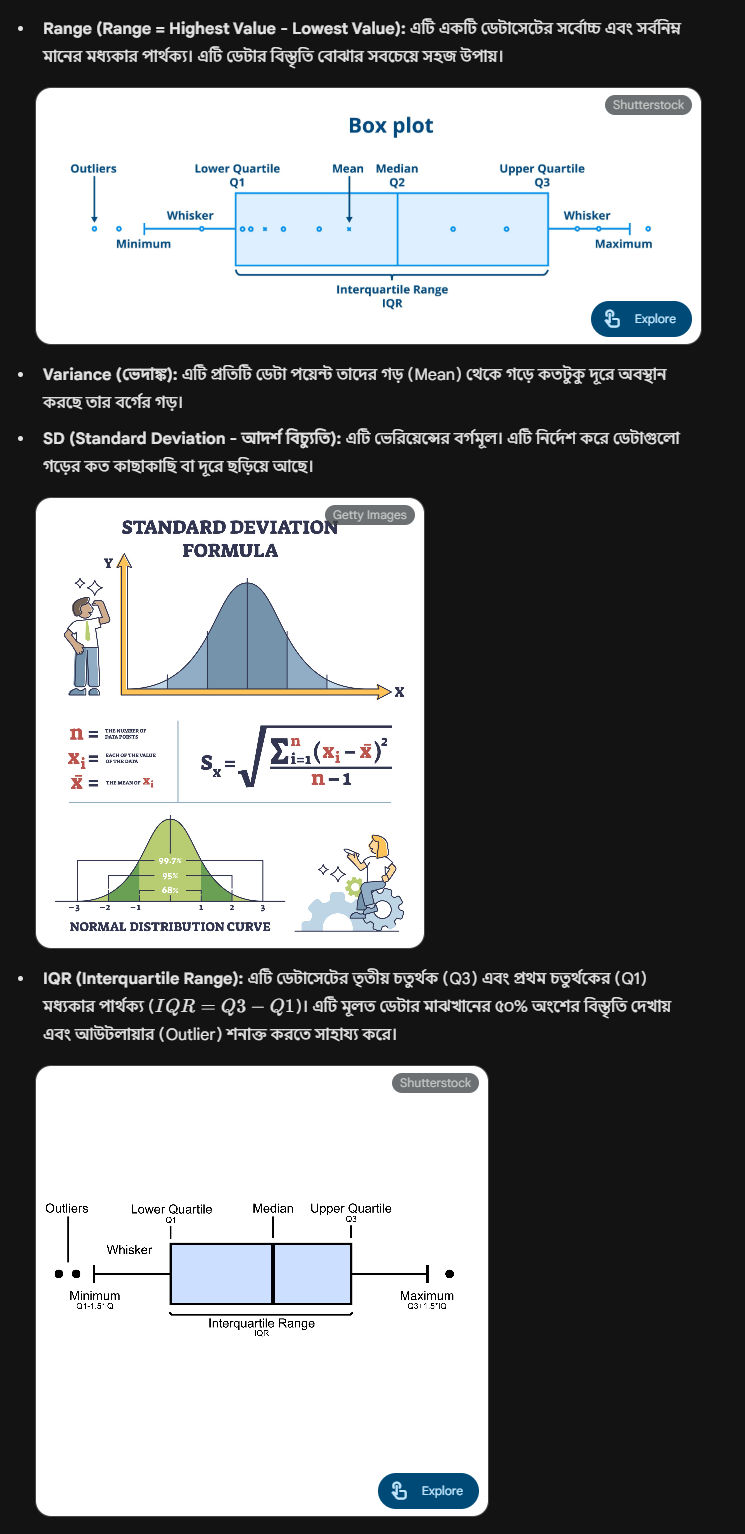
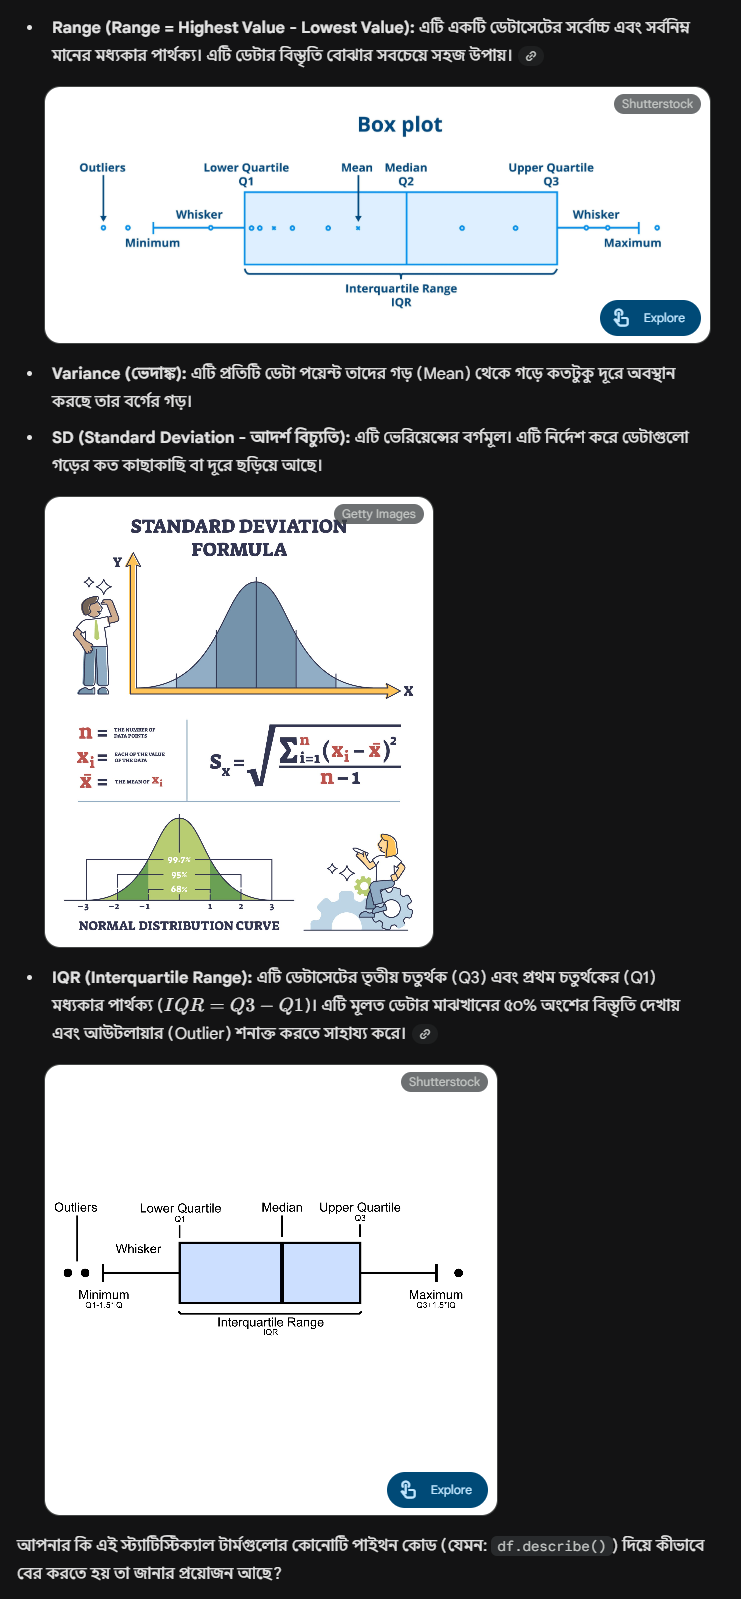
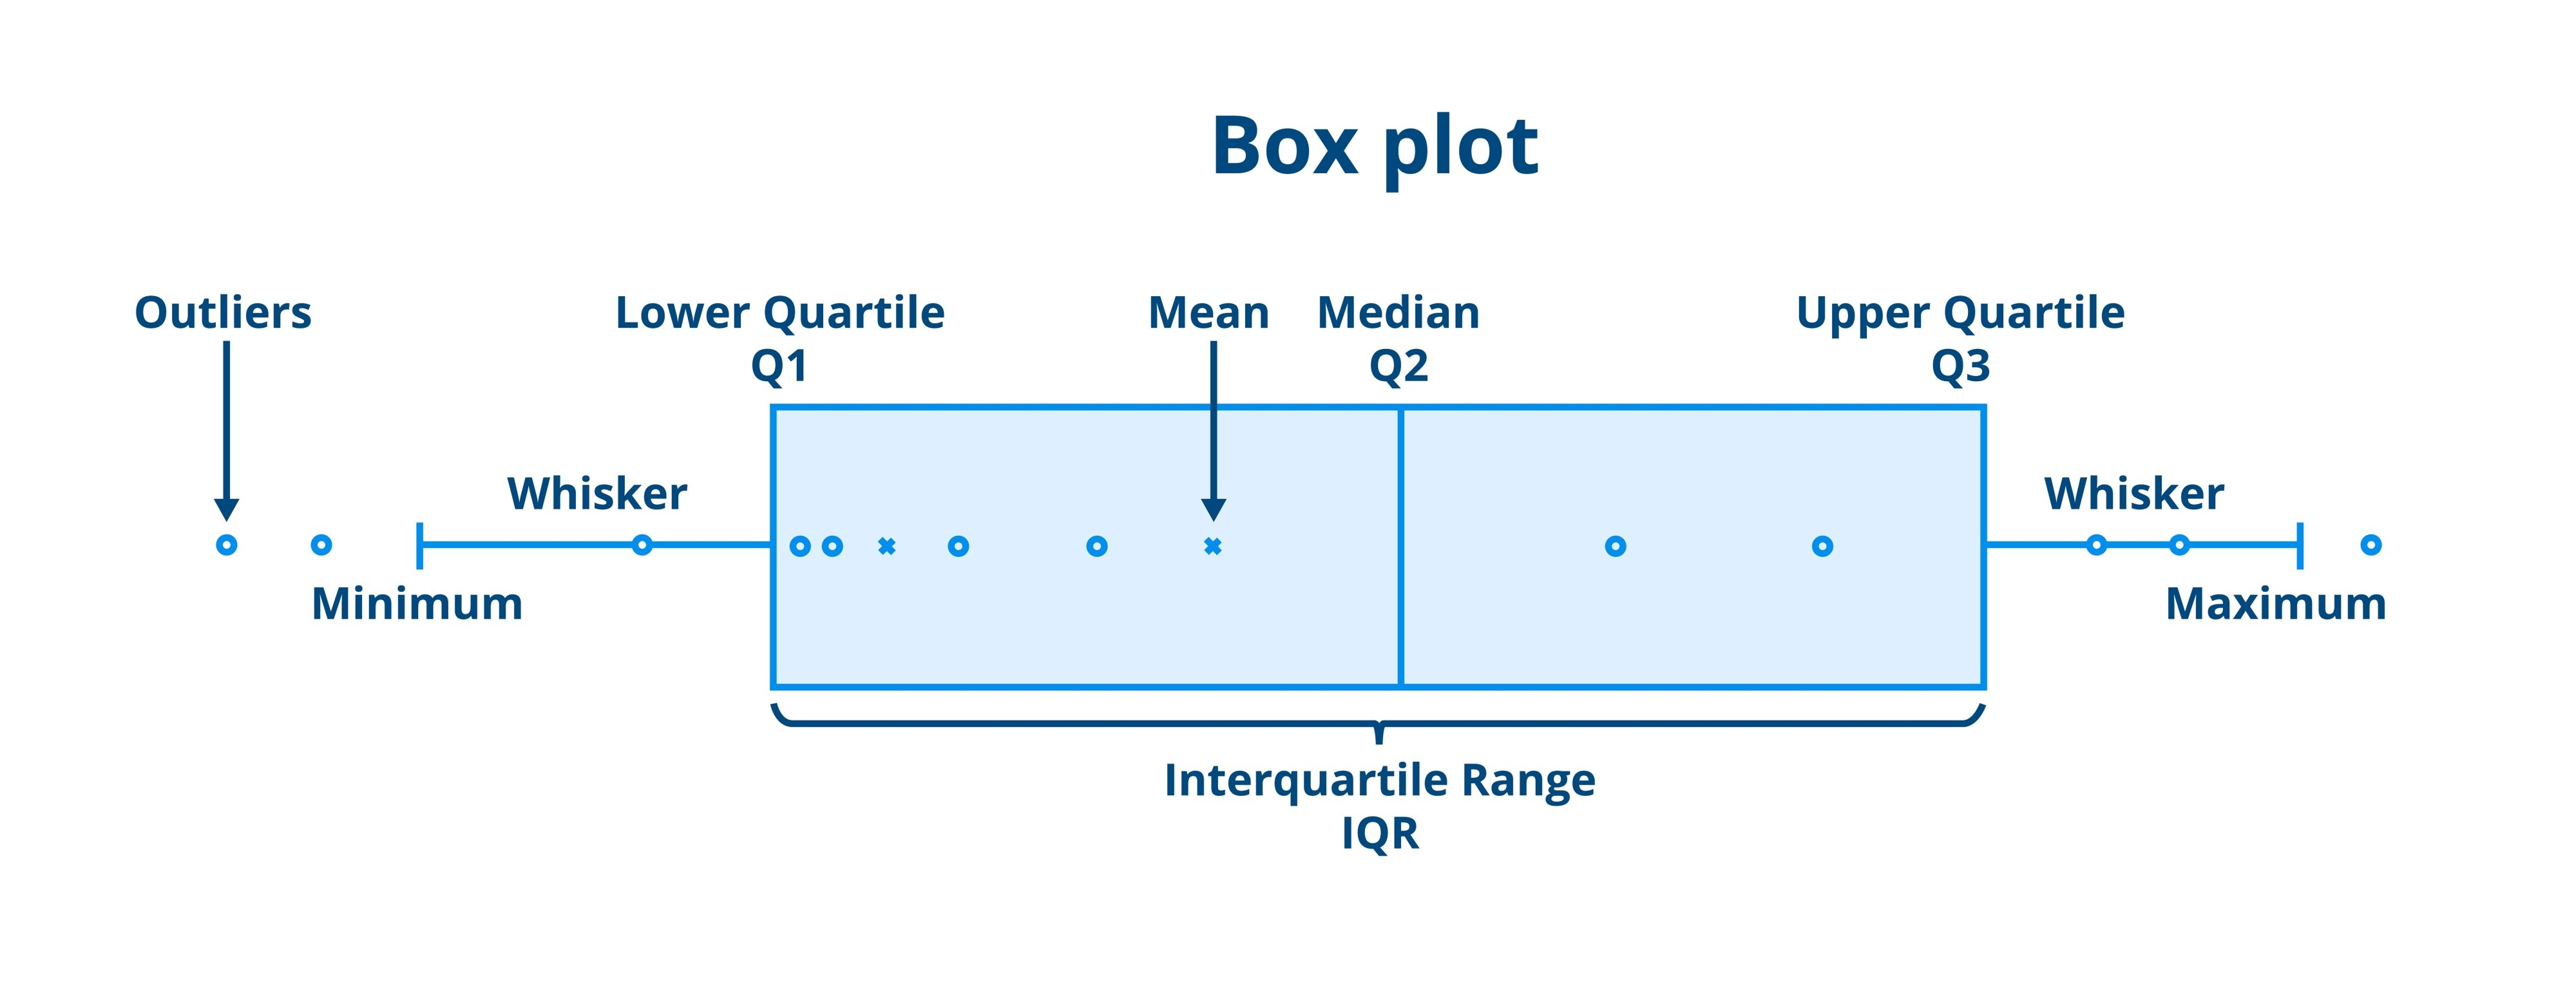
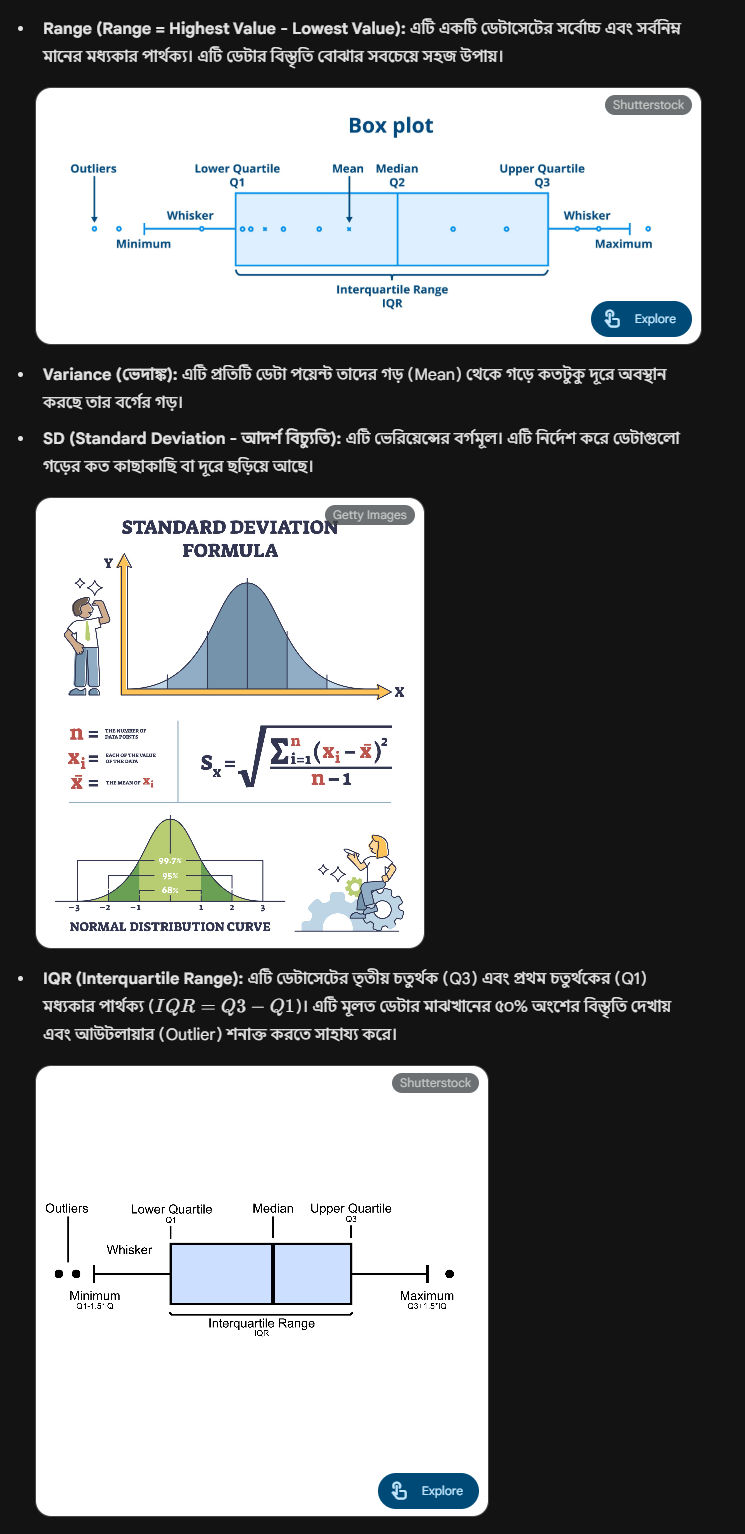

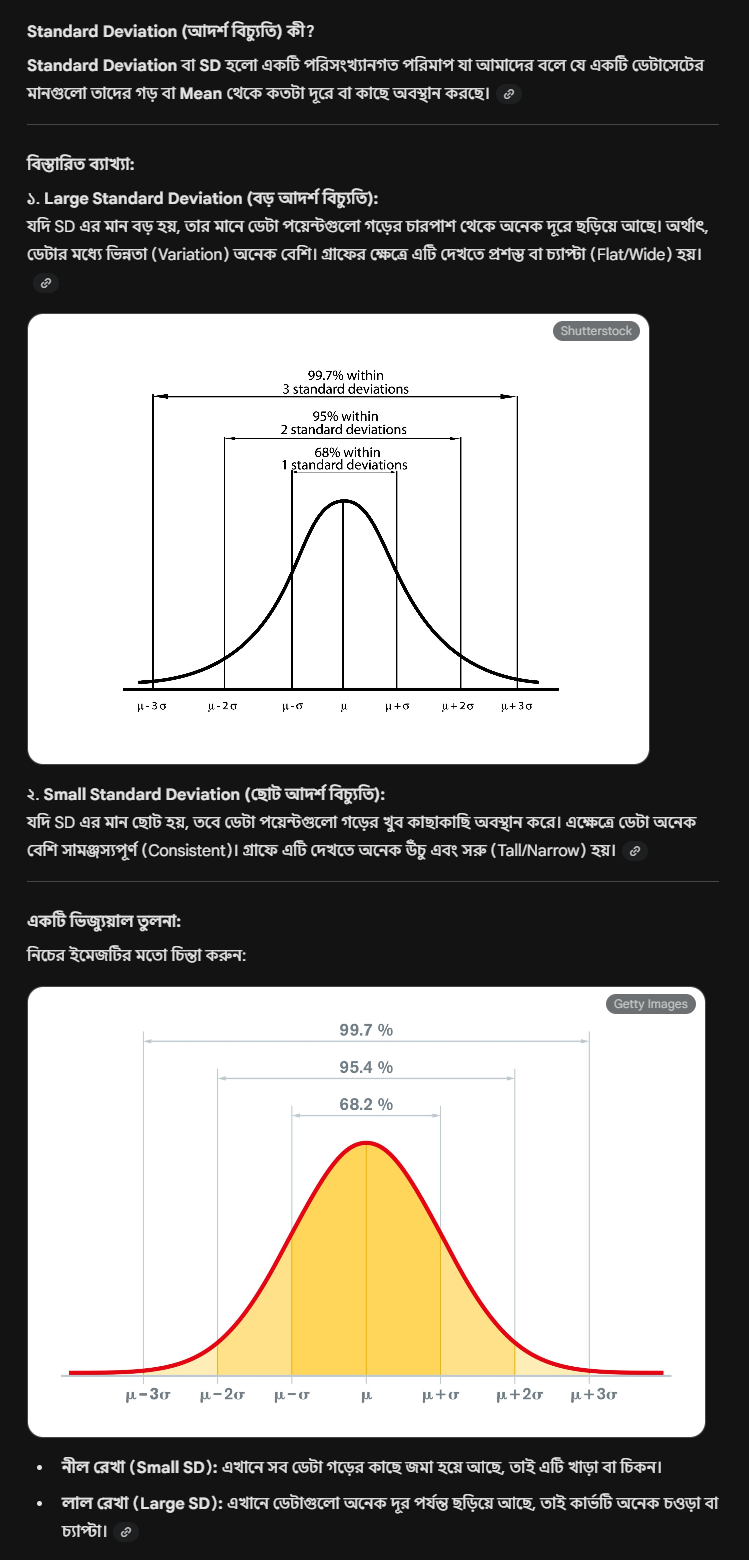

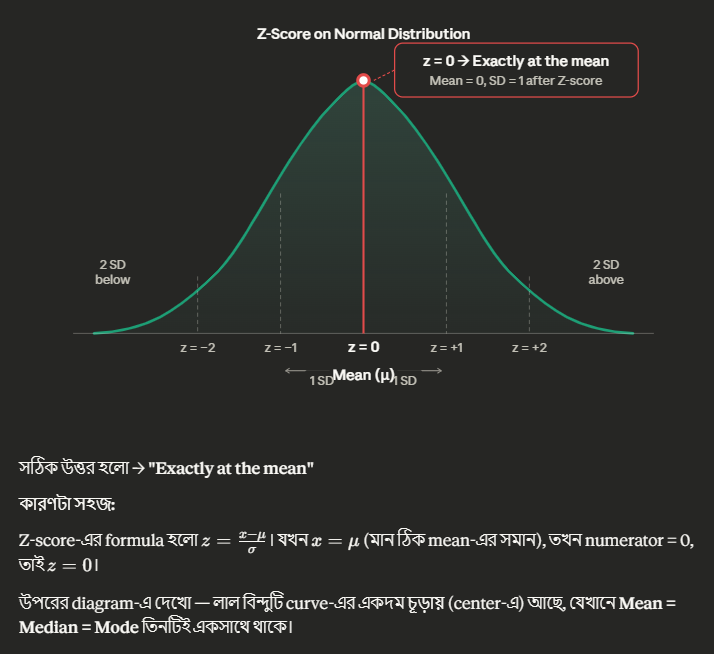

# Extra Practice Problem (Optional):

Dataset: The annual salaries (in $1000) of 20 employees in a tech company:
[45, 48, 50, 52, 55, 58, 60, 62, 65, 68, 70, 72, 75, 78, 80, 85, 90, 95, 150, 500]

Calculate:
1. Range
2. Variance 
3. Standard deviation 
4. Q2 
5. IQR (Interquartile Range)
6. Calculate the lower and upper fences for outlier detection
7. Identify any outliers using the IQR method
8. How many outliers are there and what are their values?

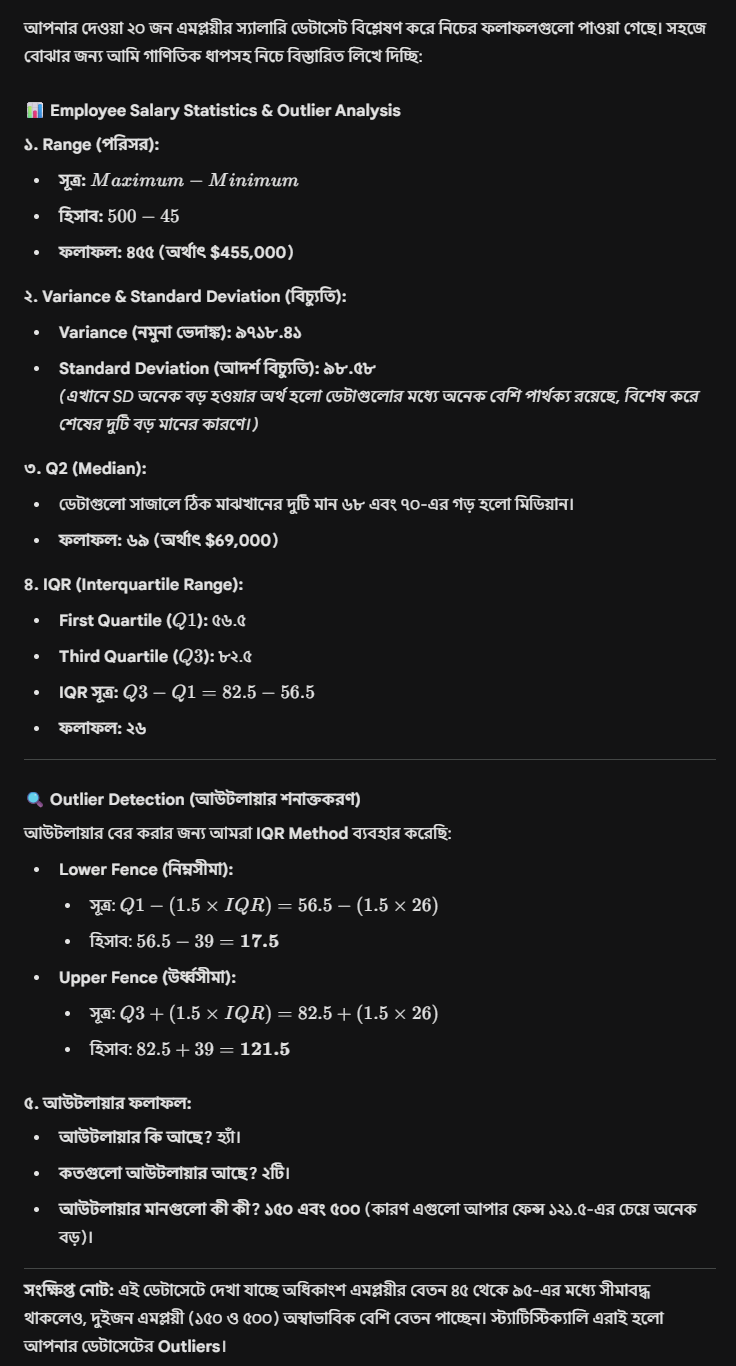

In [19]:
import numpy as np
import pandas as pd

data = [45, 48, 50, 52, 55, 58, 60, 62, 65, 68, 70, 72, 75, 78, 80, 85, 90, 95, 150, 500]
s = pd.Series(data)

range_val = s.max() - s.min()
variance = s.var() # Sample variance
std_dev = s.std() # Sample standard deviation
q1 = s.quantile(0.25)
q2 = s.quantile(0.50)
q3 = s.quantile(0.75)
iqr = q3 - q1

lower_fence = q1 - 1.5 * iqr
upper_fence = q3 + 1.5 * iqr

outliers = s[(s < lower_fence) | (s > upper_fence)].tolist()
num_outliers = len(outliers)

results = {
    "Range": range_val,
    "Variance": round(variance, 2),
    "Standard Deviation": round(std_dev, 2),
    "Q2 (Median)": q2,
    "IQR": iqr,
    "Lower Fence": lower_fence,
    "Upper Fence": upper_fence,
    "Outliers": outliers,
    "Number of Outliers": num_outliers
}

# import ace_tools as pt
print(results)

{'Range': np.int64(455), 'Variance': np.float64(9718.41), 'Standard Deviation': np.float64(98.58), 'Q2 (Median)': np.float64(69.0), 'IQR': np.float64(24.0), 'Lower Fence': np.float64(21.25), 'Upper Fence': np.float64(117.25), 'Outliers': [150, 500], 'Number of Outliers': 2}


In [20]:
import numpy as np

# Dataset
salaries = np.array([45, 48, 50, 52, 55, 58, 60, 62, 65, 68, 70, 72, 75, 78, 80, 85, 90, 95, 150, 500])

# Calculations
r_min = np.min(salaries)
r_max = np.max(salaries)
r_val = r_max - r_min

# Sample Variance & Std Dev (ddof=1)
v_val = np.var(salaries, ddof=1)
s_val = np.std(salaries, ddof=1)

# Quartiles (Method: midpoint, commonly used for boxplots with even N)
# Median (Q2) = (68 + 70) / 2 = 69
# Q1 = (55 + 58) / 2 = 56.5
# Q3 = (80 + 85) / 2 = 82.5
q1 = np.percentile(salaries, 25, method='midpoint')
q2 = np.percentile(salaries, 50, method='midpoint')
q3 = np.percentile(salaries, 75, method='midpoint')

iqr = q3 - q1

# Fences
lower_fence = q1 - 1.5 * iqr
upper_fence = q3 + 1.5 * iqr

# Outliers
outliers = salaries[(salaries < lower_fence) | (salaries > upper_fence)]

print(f"Range: {r_val}")
print(f"Sample Variance: {v_val:.2f}")
print(f"Sample Std Dev: {s_val:.2f}")
print(f"Q1: {q1}")
print(f"Q2 (Median): {q2}")
print(f"Q3: {q3}")
print(f"IQR: {iqr}")
print(f"Lower Fence: {lower_fence}")
print(f"Upper Fence: {upper_fence}")
print(f"Outliers: {outliers.tolist()}")
print(f"Count: {len(outliers)}")

Range: 455
Sample Variance: 9718.41
Sample Std Dev: 98.58
Q1: 56.5
Q2 (Median): 69.0
Q3: 82.5
IQR: 26.0
Lower Fence: 17.5
Upper Fence: 121.5
Outliers: [150, 500]
Count: 2


---